# Comprendre l'effet de JDAC sur l'épaisseur corticale — pas à pas

**La question :** est-ce que JDAC *corrige* le mouvement, ou est-ce qu'il *lisse* juste l'image ?

Le principe :
- 1 scan = 1 image, défini par : sujet × condition (`still` / `nodding` / `shaking`) × bras (`brute` / `preproc` / `jdac`).
- Quand le mouvement augmente (`still` → `shaking`), l'épaisseur corticale mesurée par FreeSurfer **baisse**.
- Si JDAC **corrige** le mouvement : sur ses images, l'épaisseur dépend **moins** du mouvement → la pente épaisseur~mouvement est **plus plate** que sur le brut.
- Si JDAC **lisse** seulement : il décale l'épaisseur (offset) mais la pente reste pareille.

On va le voir étape par étape. Lance chaque cellule avec **Maj+Entrée**. Rien n'est caché : à chaque étape tu vois le tableau, le chiffre ou le graphique.

## 1. Réglages et chargement des données

In [1]:
# Imports. On reste en Python, dans l'env cortical-motion.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
import warnings; warnings.filterwarnings("ignore")  # cache le bruit de convergence des modèles

# SUFFIX = "" -> données NATIVES (ce qu'on a déjà).
# Plus tard, pour le pipeline RIGIDE, mets SUFFIX = "_rigid" et relance tout le notebook.
SUFFIX = ""

HOME = Path.home()
REPO  = HOME / "Documents/jdac-motion-correction"
DERIV = HOME / "Documents/derivatives/ds004332"
BRUTE_CSV    = REPO / "results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv"
AGIT_CSV     = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"
PARTICIPANTS = HOME / "Documents/raw_datasets/ds004332/participants.tsv"
COND = {"run-01": "still", "run-02": "nodding", "run-03": "shaking"}
print("Chemins prêts. SUFFIX =", repr(SUFFIX), "(donc pipeline", "rigide)" if SUFFIX else "natif)")

Chemins prêts. SUFFIX = '' (donc pipeline natif)


On a 3 bras rangés dans **deux dispositions différentes** :
- le **brut** est en **format empilé** (1 ligne = 1 mesure, c.-à-d. 1 scan × 1 région) ;
- **preproc** et **jdac** sont en **format en colonnes** (1 ligne = 1 scan, 1 colonne par région).

On les met tous dans **un seul tableau empilé** (1 ligne = 1 mesure) où chaque ligne porte : un sujet, un run, un hémisphère, une région, une épaisseur, un bras.

In [2]:
def load_brute():
    # Brut : format empilé (1 ligne = 1 mesure), colonne ThickAvg. On retire sub-01_run-03 (échec FreeSurfer, ThickAvg=0).
    d = pd.read_csv(BRUTE_CSV)
    d = d[d["ThickAvg"] > 0].copy()
    d["run"] = d["subject"].str.split("_").str[1]
    d["subject"] = d["subject"].str.split("_").str[0]
    d = d.rename(columns={"ThickAvg": "thickness"})
    d["arm"] = "brute"
    return d[["subject", "run", "hemi", "region", "thickness", "arm"]]

def load_wide(arm):
    # preproc / jdac : format en colonnes (1 ligne = 1 scan, 1 colonne par région). On le "déplie" en format empilé.
    frames = []
    for hemi in ["lh", "rh"]:
        w = pd.read_csv(DERIV / f"thickness_{arm}{SUFFIX}_{hemi}.csv", sep="\t")
        w = w.rename(columns={w.columns[0]: "id"})
        cols = [c for c in w.columns if c.endswith("_thickness") and "MeanThickness" not in c]
        long = w.melt(id_vars="id", value_vars=cols, var_name="rr", value_name="thickness")
        long["hemi"] = hemi
        long["region"] = (long["rr"].str.replace(f"{hemi}_", "", regex=False)
                                     .str.replace("_thickness", "", regex=False))
        frames.append(long)
    d = pd.concat(frames, ignore_index=True)
    d["subject"] = d["id"].str.split("_").str[0]
    d["run"] = d["id"].str.split("_").str[1]
    d["arm"] = arm
    return d[["subject", "run", "hemi", "region", "thickness", "arm"]]

# On empile les 3 bras
thick = pd.concat([load_brute(), load_wide("preproc"), load_wide("jdac")], ignore_index=True)
thick = thick[thick["thickness"] > 0].copy()

# On rattache le score de mouvement (Agitation) et l'âge/sexe
agit  = pd.read_csv(AGIT_CSV).rename(columns={"condition": "run", "sub": "subject", "motion": "agitation"})
demog = pd.read_csv(PARTICIPANTS, sep="\t").rename(columns={"participant_id": "subject"})
demog["sex_bin"] = (demog["sex"] == "F").astype(int)

df = thick.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="inner")
df = df.merge(demog[["subject", "age", "sex_bin"]], on="subject", how="left")
df["condition"] = df["run"].map(COND)

print("Tableau df :", df.shape[0], "lignes (région × scan × bras)")
print("Nombre de scans par bras :")
print(df.groupby("arm").apply(lambda x: x.groupby(["subject","run"]).ngroups))
df.head()

Tableau df : 13396 lignes (région × scan × bras)
Nombre de scans par bras :
arm
brute      65
jdac       66
preproc    66
dtype: int64


,subject,run,hemi,region,thickness,arm,agitation,age,sex_bin,condition
0,sub-01,run-01,lh,bankssts,2.679,brute,0.199097,21,0,still
1,sub-01,run-01,lh,caudalanteriorcingulate,2.487,brute,0.199097,21,0,still
2,sub-01,run-01,lh,caudalmiddlefrontal,2.859,brute,0.199097,21,0,still
3,sub-01,run-01,lh,cuneus,1.945,brute,0.199097,21,0,still
4,sub-01,run-01,lh,entorhinal,3.361,brute,0.199097,21,0,still


## 2. Le tableau de travail : une épaisseur globale par scan

68 régions par scan, c'est trop pour voir la vue d'ensemble. On commence par **moyenner les 68 régions**
pour avoir **une seule épaisseur par scan**. (On regardera région par région plus tard.)

In [3]:
g = (df.groupby(["subject", "run", "condition", "arm"])
       .agg(thickness=("thickness", "mean"),
            agitation=("agitation", "first"),
            age=("age", "first"),
            sex_bin=("sex_bin", "first"))
       .reset_index())

print(g.shape[0], "lignes (1 par scan × bras). Exemple sub-01 :")
g[g["subject"] == "sub-01"].sort_values(["arm", "run"])

197 lignes (1 par scan × bras). Exemple sub-01 :


,subject,run,condition,arm,thickness,agitation,age,sex_bin
0,sub-01,run-01,still,brute,2.739765,0.199097,21,0
3,sub-01,run-02,nodding,brute,2.542824,0.255442,21,0
1,sub-01,run-01,still,jdac,2.639456,0.199097,21,0
4,sub-01,run-02,nodding,jdac,2.490779,0.255442,21,0
6,sub-01,run-03,shaking,jdac,2.372029,3.161867,21,0
2,sub-01,run-01,still,preproc,2.691985,0.199097,21,0
5,sub-01,run-02,nodding,preproc,2.564985,0.255442,21,0
7,sub-01,run-03,shaking,preproc,2.432559,3.161867,21,0


## 3. LE graphique qui répond à la question

En **x** : le score de mouvement. En **y** : l'épaisseur. **Un nuage + une droite par bras.**

- Regarde la **pente** de chaque droite. Le brut (gris) descend : plus de mouvement → moins d'épaisseur.
- Si la droite **jdac** (rouge) est **plus plate** que le brut → JDAC réduit l'effet du mouvement (= correction).
- Si jdac est juste **décalée** mais avec **la même pente** → c'est du lissage (offset), pas de la correction.

Pente épaisseur ~ mouvement (mm par unité d'Agitation) :
  brute   : -0.0679   (p=3.4e-05)
  preproc : -0.0468   (p=0.00049)
  jdac    : -0.0297   (p=0.028)


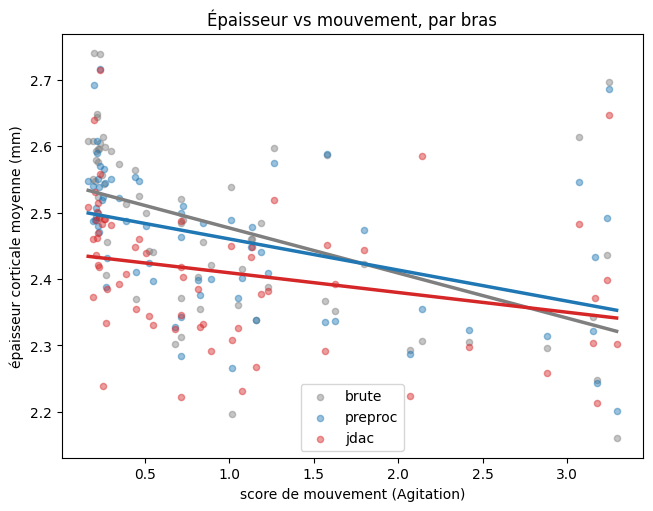

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = {"brute": "tab:gray", "preproc": "tab:blue", "jdac": "tab:red"}
print("Pente épaisseur ~ mouvement (mm par unité d'Agitation) :")
for arm in ["brute", "preproc", "jdac"]:
    sub = g[g["arm"] == arm]
    ax.scatter(sub["agitation"], sub["thickness"], s=20, alpha=0.45, color=colors[arm], label=arm)
    sl, inter, r, p, se = stats.linregress(sub["agitation"], sub["thickness"])
    xs = np.linspace(g["agitation"].min(), g["agitation"].max(), 50)
    ax.plot(xs, inter + sl * xs, color=colors[arm], lw=2.5)
    print(f"  {arm:8s}: {sl:+.4f}   (p={p:.2g})")
ax.set_xlabel("score de mouvement (Agitation)")
ax.set_ylabel("épaisseur corticale moyenne (mm)")
ax.set_title("Épaisseur vs mouvement, par bras")
ax.legend()
plt.show()

## 4. E1 — moyennes par condition (descriptif)

Trois lectures, sans test ni modèle :
1. **Épaisseur moyenne** par condition × bras (les valeurs brutes).
2. **Effet du mouvement** : variation vs le `still` du **même bras** de la moyenne globale de l'epaisseur (sujets et runs confondus) → de combien le mouvement grignote l'épaisseur *dans chaque pipeline*. Si jdac perd moins que le brut, c'est l'aplatissement.
3. **Écart vs le brut** par condition de la moyenne globale de l'epaisseur (sujets et runs confondus)→ ce que preproc/jdac changent par rapport à l'image brute. Si l'écart jdac est ~constant sur les 3 conditions, c'est la signature d'un lissage uniforme.

In [5]:
# Tableau 1 : épaisseur moyenne (mm) par condition x bras
piv = g.pivot_table(index="condition", columns="arm", values="thickness", aggfunc="mean")
piv = piv.reindex(["still", "nodding", "shaking"])[["brute", "preproc", "jdac"]]
print("Tableau 1 — Épaisseur moyenne (mm) par condition × bras :")
print(piv.round(3).to_string())

# Tableau 2 : effet du mouvement = variation vs le still DU MÊME bras (%)
motion = 100 * (piv - piv.loc["still"]) / piv.loc["still"]
print("\nTableau 2 — Effet du mouvement : variation vs le still du MÊME bras (%)")
print("  (de combien le mouvement grignote l'épaisseur dans chaque pipeline)")
print(motion.round(2).to_string())

# Tableau 3 : écart de chaque bras vs le brut, par condition (%)
offset = pd.DataFrame({
    "preproc_vs_brut_%": 100 * (piv["preproc"] - piv["brute"]) / piv["brute"],
    "jdac_vs_brut_%":    100 * (piv["jdac"]    - piv["brute"]) / piv["brute"],
})
print("\nTableau 3 — Écart de chaque bras vs le brut, par condition (%)")
print("  (ce que preproc / jdac changent par rapport à l'image brute)")
print(offset.round(2).to_string())

Tableau 1 — Épaisseur moyenne (mm) par condition × bras :
arm        brute  preproc   jdac
condition                       
still      2.595    2.544  2.479
nodding    2.503    2.490  2.424
shaking    2.332    2.346  2.325

Tableau 2 — Effet du mouvement : variation vs le still du MÊME bras (%)
  (de combien le mouvement grignote l'épaisseur dans chaque pipeline)
arm        brute  preproc  jdac
condition                      
still       0.00     0.00  0.00
nodding    -3.55    -2.10 -2.24
shaking   -10.12    -7.76 -6.21

Tableau 3 — Écart de chaque bras vs le brut, par condition (%)
  (ce que preproc / jdac changent par rapport à l'image brute)
           preproc_vs_brut_%  jdac_vs_brut_%
condition                                   
still                  -1.97           -4.47
nodding                -0.50           -3.16
shaking                 0.61           -0.31


## 4 bis. Par niveau de mouvement RÉEL (score Agitation)

Le label `still`/`nodding`/`shaking` n'est qu'une **consigne** donnée au sujet. En vrai, `nodding` et `shaking` se **chevauchent** beaucoup en mouvement mesuré. Ici on regroupe plutôt par **score Agitation réel**, en 3 tiers de taille égale (`bas` / `moyen` / `fort`). C'est une vue **complémentaire** à E1 (on garde E1, on ajoute).

À regarder : (1) l'écart jdac↔brut **rétrécit-il** quand le mouvement augmente ? (2) à fort mouvement, un bras **remonte-t-il** vers la valeur du niveau bas, ou tout reste-t-il coincé en bas ?

Bornes des niveaux (score Agitation) :
        count   min   max
niveau                   
bas        22  0.16  0.28
moyen      22  0.30  1.05
fort       22  1.07  3.29

Epaisseur moyenne (mm) par niveau de mouvement reel x bras :
arm     brute  preproc   jdac
niveau                       
bas     2.583    2.534  2.473
moyen   2.442    2.436  2.376
fort    2.408    2.410  2.378

Ecart jdac vs brut par niveau (%) :
niveau
bas     -4.24
moyen   -2.70
fort    -1.24


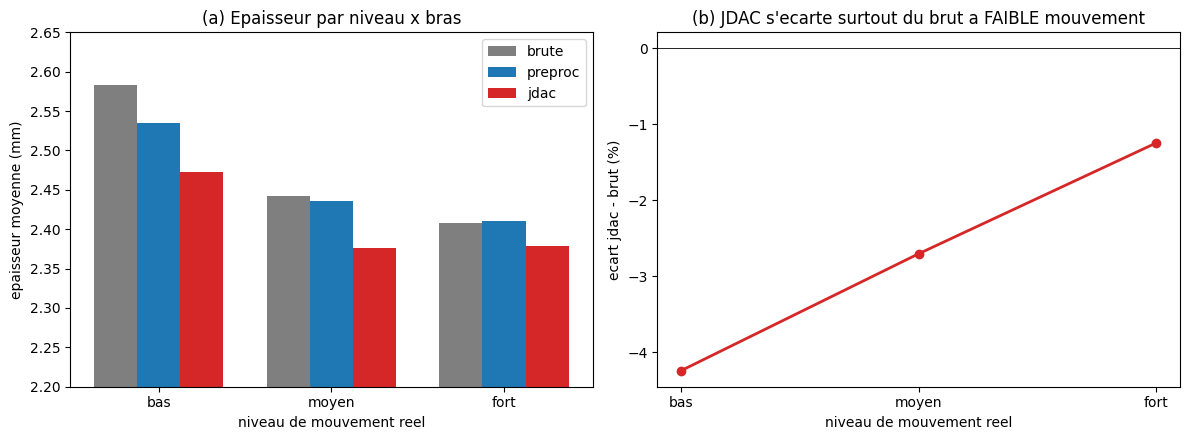

In [6]:
# Regroupe les scans par niveau de mouvement RÉEL (3 tiers du score Agitation)
scans = g[["subject", "run", "agitation"]].drop_duplicates().copy()
scans["niveau"] = pd.qcut(scans["agitation"], 3, labels=["bas", "moyen", "fort"])
gb = g.merge(scans[["subject", "run", "niveau"]], on=["subject", "run"])

bornes = scans.groupby("niveau", observed=True)["agitation"].agg(["count", "min", "max"]).round(2)
print("Bornes des niveaux (score Agitation) :")
print(bornes.to_string())

pivb = (gb.pivot_table(index="niveau", columns="arm", values="thickness", aggfunc="mean", observed=True)
          .reindex(["bas", "moyen", "fort"])[["brute", "preproc", "jdac"]])
gap = 100 * (pivb["jdac"] - pivb["brute"]) / pivb["brute"]
print("\nEpaisseur moyenne (mm) par niveau de mouvement reel x bras :")
print(pivb.round(3).to_string())
print("\nEcart jdac vs brut par niveau (%) :")
print(gap.round(2).to_string())

# --- Graphiques ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"brute": "tab:gray", "preproc": "tab:blue", "jdac": "tab:red"}
xpos = np.arange(3); w = 0.25
for i, arm in enumerate(["brute", "preproc", "jdac"]):
    ax[0].bar(xpos + (i - 1) * w, pivb[arm].values, w, label=arm, color=colors[arm])
ax[0].set_xticks(xpos); ax[0].set_xticklabels(["bas", "moyen", "fort"])
ax[0].set_ylim(2.2, 2.65); ax[0].set_ylabel("epaisseur moyenne (mm)")
ax[0].set_xlabel("niveau de mouvement reel"); ax[0].set_title("(a) Epaisseur par niveau x bras")
ax[0].legend()
ax[1].plot(["bas", "moyen", "fort"], gap.values, "o-", color="tab:red", lw=2)
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("ecart jdac - brut (%)"); ax[1].set_xlabel("niveau de mouvement reel")
ax[1].set_title("(b) JDAC s'ecarte surtout du brut a FAIBLE mouvement")
plt.tight_layout(); plt.show()

## 5. E2 — la pente PAR SUJET (vue intra-sujet, plus fiable)

Chaque sujet a 3 scans (`still`, `nodding`, `shaking`). Pour **un sujet et un bras**, on trace une droite sur ces 3 points :
sa pente = de combien SON épaisseur baisse quand SON mouvement augmente.

On compare ensuite les pentes entre bras avec un **test apparié** (mêmes sujets) : c'est plus fiable que de tout mélanger,
parce qu'on compare chaque sujet à lui-même.

Pente médiane par bras :
arm
brute     -0.1601
jdac      -0.0686
preproc   -0.1064
Name: slope, dtype: float64


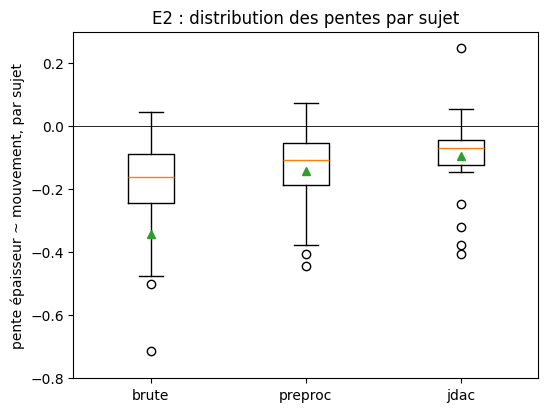


Tests appariés (Wilcoxon) sur les pentes par sujet :
  brute vs jdac (n=22): médiane brute=-0.1601, jdac=-0.0686, p=0.00109
  preproc vs jdac (n=22): médiane preproc=-0.1064, jdac=-0.0686, p=0.147


In [7]:
rows = []
for (subj, arm), sub in g.groupby(["subject", "arm"]):
    if len(sub) < 2 or sub["agitation"].std() == 0:
        continue
    sl = stats.linregress(sub["agitation"], sub["thickness"]).slope
    rows.append(dict(subject=subj, arm=arm, slope=sl))
pentes = pd.DataFrame(rows)

print("Pente médiane par bras :")
print(pentes.groupby("arm")["slope"].median().round(4))

fig, ax = plt.subplots(figsize=(6, 4.5))
data = [pentes[pentes["arm"] == a]["slope"] for a in ["brute", "preproc", "jdac"]]
ax.boxplot(data, labels=["brute", "preproc", "jdac"], showmeans=True)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylim(-0.8, 0.3)  # axe borné : pentes sur 3 points, quelques outliers hors champ
ax.set_ylabel("pente épaisseur ~ mouvement, par sujet")
ax.set_title("E2 : distribution des pentes par sujet")
plt.show()

print("\nTests appariés (Wilcoxon) sur les pentes par sujet :")
wide = pentes.pivot(index="subject", columns="arm", values="slope")
for a, b in [("brute", "jdac"), ("preproc", "jdac")]:
    pair = wide[[a, b]].dropna()
    w, p = stats.wilcoxon(pair[a], pair[b])
    print(f"  {a} vs {b} (n={len(pair)}): médiane {a}={pair[a].median():+.4f}, "
          f"{b}={pair[b].median():+.4f}, p={p:.3g}")

## 6. E3 — le modèle mixte (le test propre)

On met tout dans un seul modèle, en corrigeant pour l'âge et le sexe, et en tenant compte du fait que les 3 runs
viennent du même sujet (`(1|sujet)`). Référence = le brut.

```
épaisseur ~ âge + sexe + mouvement × bras + (1|sujet)
```

Trois choses à lire :
- **pente du brut** = coefficient de `agitation` (effet du mouvement sur le brut).
- **offset** d'un bras = décalage global vs brut (`C(arm)[T.preproc/jdac]`).
- **changement de pente** d'un bras = `agitation:C(arm)[...]` → **C'EST LE VERDICT.** S'il est positif et significatif pour jdac (pente moins négative que le brut), JDAC aplatit l'effet du mouvement = correction. Sinon = lissage.

In [8]:
g2 = g.copy()
g2["arm"] = pd.Categorical(g2["arm"], categories=["brute", "preproc", "jdac"])
fit = smf.mixedlm("thickness ~ age + sex_bin + agitation * C(arm, Treatment('brute'))",
                  g2, groups=g2["subject"]).fit(reml=True, method="powell", disp=False)

base = "C(arm, Treatment('brute'))"
def coef(name):
    return fit.params[name], fit.pvalues[name]

sl_b,   p_slb  = coef("agitation")
off_p,  p_offp = coef(f"{base}[T.preproc]")
off_j,  p_offj = coef(f"{base}[T.jdac]")
chg_p,  p_chgp = coef(f"agitation:{base}[T.preproc]")
chg_j,  p_chgj = coef(f"agitation:{base}[T.jdac]")

print(f"pente brut             : {sl_b:+.4f}  (p={p_slb:.2g})")
print(f"offset preproc         : {off_p:+.4f}  (p={p_offp:.2g})")
print(f"offset jdac            : {off_j:+.4f}  (p={p_offj:.2g})")
print(f"changement pente preproc: {chg_p:+.4f}  (p={p_chgp:.2g})")
print(f"changement pente jdac   : {chg_j:+.4f}  (p={p_chgj:.2g})   <-- LE VERDICT")
print(f"\n=> pentes : brut {sl_b:+.4f} | preproc {sl_b+chg_p:+.4f} | jdac {sl_b+chg_j:+.4f}")
if p_chgj < 0.05 and abs(sl_b + chg_j) < abs(sl_b):
    print("INTERPRÉTATION : pente jdac aplatie significativement -> JDAC réduit l'effet du mouvement.")
else:
    print("INTERPRÉTATION : pente jdac pas distincte du brut -> JDAC ne corrige pas (offset / lissage).")

pente brut             : -0.0796  (p=4.5e-10)
offset preproc         : -0.0364  (p=0.11)
offset jdac            : -0.1044  (p=5.6e-06)
changement pente preproc: +0.0190  (p=0.26)
changement pente jdac   : +0.0361  (p=0.033)   <-- LE VERDICT

=> pentes : brut -0.0796 | preproc -0.0606 | jdac -0.0435
INTERPRÉTATION : pente jdac aplatie significativement -> JDAC réduit l'effet du mouvement.


## Comment lire le verdict

- **Le graphique de l'étape 3** te donne déjà l'intuition : la droite jdac est-elle plus plate que le brut, ou juste décalée ?
- **E2** te dit si, sujet par sujet, la pente diminue avec jdac (test apparié).
- **E3** te donne le test formel : le *changement de pente jdac* est le chiffre qui tranche.

**Pour le rigide (plus tard) :** remonte à la cellule de l'étape 1, mets `SUFFIX = "_rigid"`, et relance tout le notebook (menu *Run > Run All Cells*). Tu compareras les deux verdicts.

C'est ton outil maintenant : change ce que tu veux, ajoute des cellules, refais les graphiques. Tout est visible.